This is to generate Daily Return as Adj Close for model tuning

In [59]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [60]:
import warnings
warnings.filterwarnings("ignore")

In [61]:
# Data source from yfinance as below
#   tentatively retreive 3 years stock data

company = "0005.HK"
df_HKstock = yf.download(company, start="2023-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
2023-01-06,40.235821,40.582682,40.043120,40.428521,30945589
2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...
2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439072,119.173196,117.053708,119.173196,13132355


In [62]:
# Save copy to CSV
df_HKstock.to_csv('0005.HK260102.csv')

In [63]:
#
df_source = pd.read_csv("0005.HK260102.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
1,2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2,2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
3,2023-01-06,40.235821,40.582682,40.043120,40.428521,30945589
4,2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...,...
730,2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
731,2025-12-24,119.365891,119.365891,119.365891,119.365891,0
732,2025-12-29,117.439072,119.173196,117.053708,119.173196,13132355
733,2025-12-30,118.498825,118.787850,116.764693,116.764693,11747636


In [64]:
# Set Date
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
1,2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2,2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
3,2023-01-06,40.235821,40.582682,40.043120,40.428521,30945589
4,2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...,...
730,2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
731,2025-12-24,119.365891,119.365891,119.365891,119.365891,0
732,2025-12-29,117.439072,119.173196,117.053708,119.173196,13132355
733,2025-12-30,118.498825,118.787850,116.764693,116.764693,11747636


In [65]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    735 non-null    datetime64[ns]
 1   Close   735 non-null    float64       
 2   High    735 non-null    float64       
 3   Low     735 non-null    float64       
 4   Open    735 non-null    float64       
 5   Volume  735 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 34.6 KB


In [66]:
# Set Date as index - time series data
df_source = df_source.set_index('Date', ) 
df_source.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 735 entries, 2023-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   735 non-null    float64
 1   High    735 non-null    float64
 2   Low     735 non-null    float64
 3   Open    735 non-null    float64
 4   Volume  735 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.5 KB


In [67]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
2023-01-06,40.235821,40.582682,40.043120,40.428521,30945589
2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...
2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439072,119.173196,117.053708,119.173196,13132355


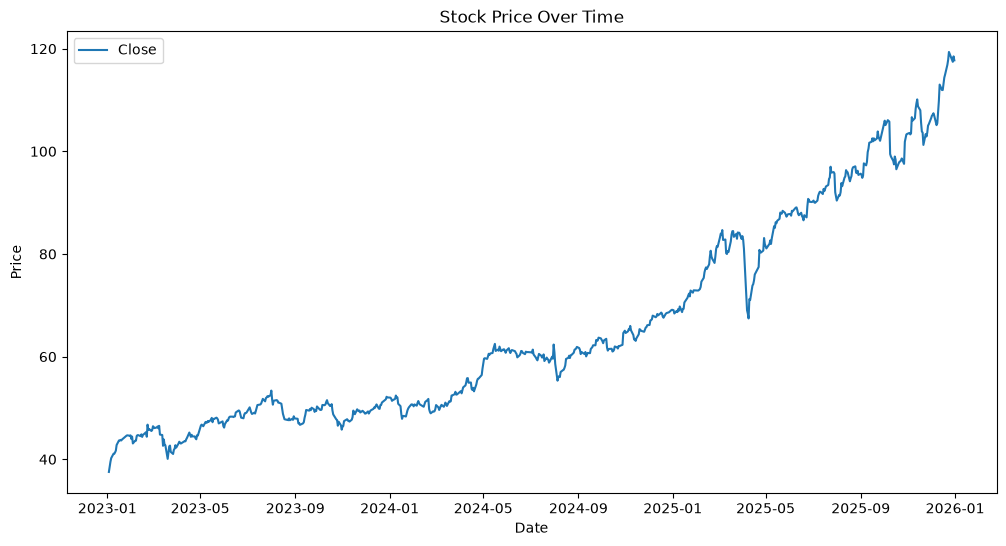

In [68]:
# To visual data 
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close')
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

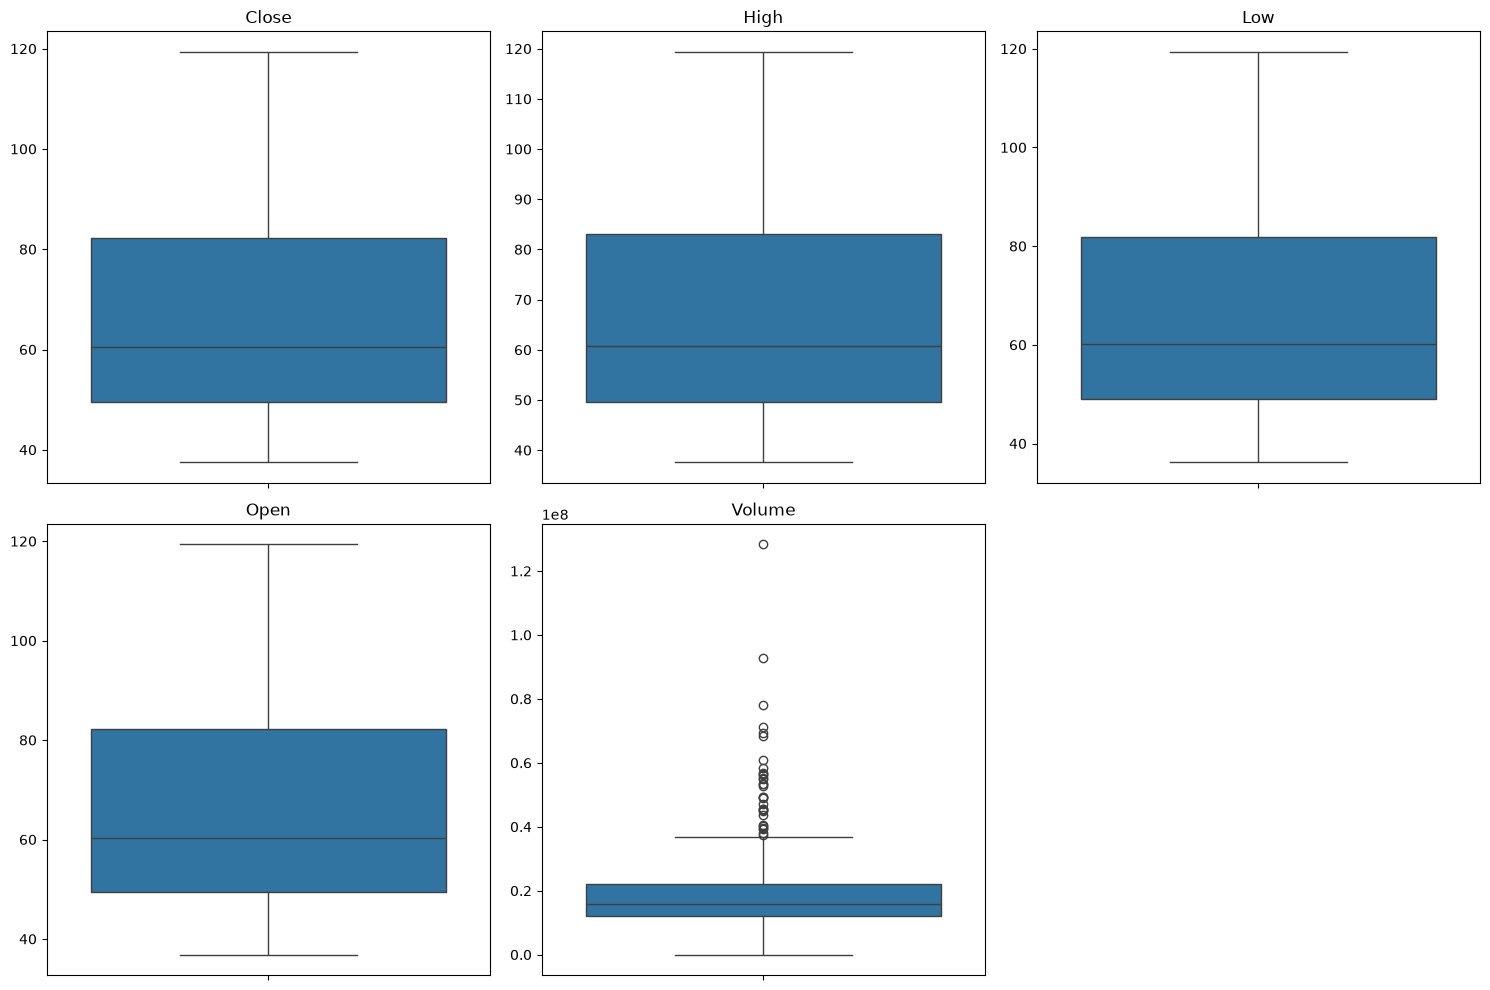

In [69]:
# To study data outliers and variations

#import math
#import matplotlib.pyplot as plt
#import seaborn as sns

num_cols = 3
num_features = len(df.columns)
num_rows = math.ceil(num_features / num_cols)

fig = plt.figure(figsize=(15, num_rows * 5))

for i, x in enumerate(df.columns, start=1):
    plt.subplot(num_rows, num_cols, i)
    ax = sns.boxplot(df[x])
    ax.set(xlabel=None)
    plt.title(str(x), loc='center')
    plt.xlabel(None)
    plt.ylabel(None)

plt.tight_layout()
plt.show()

Box plots apply to identify outliers; may identify anomalous trading days or incorrect data points

In [70]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [71]:
# This is preserve as for handling missing values, if applicable
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
2023-01-06,40.235821,40.582682,40.043120,40.428521,30945589
2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...
2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439072,119.173196,117.053708,119.173196,13132355


In [72]:
# Calculate moving averages and daily returns

df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [73]:
# To check NaN
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602,NaN,NaN,NaN
2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070,NaN,NaN,0.026694
2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352,NaN,NaN,0.025000
2023-01-06,40.235821,40.582682,40.043120,40.428521,30945589,NaN,NaN,0.018537
2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005,NaN,NaN,0.021073
2023-01-10,41.083702,41.122242,40.775383,40.968084,15923846,NaN,NaN,0.000000
2023-01-11,41.353481,41.546182,41.083699,41.237860,19895897,NaN,NaN,0.006567
2023-01-12,41.700348,41.700348,41.353490,41.469108,18594710,NaN,NaN,0.008388
2023-01-13,42.779472,42.779472,42.355532,42.394072,31176673,NaN,NaN,0.025878


In [74]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-03-16,42.828850,42.948038,42.352089,42.431551,26622653,45.351556,43.985588,-0.023551
2023-03-17,42.749393,42.908314,42.193174,42.908314,19300748,45.245994,44.089815,-0.001855
2023-03-20,40.087490,41.954795,39.491541,41.875336,56886469,44.986140,44.120764,-0.062268
2023-03-21,41.239651,41.358839,40.723161,41.319109,36238398,44.828215,44.155486,0.028741
2023-03-22,42.511005,42.908305,41.994515,42.034248,29346962,44.616311,44.200989,0.030828
...,...,...,...,...,...,...,...,...
2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666,109.548791,105.471438,0.008244
2025-12-24,119.365891,119.365891,119.365891,119.365891,0,110.333966,105.909449,0.013083
2025-12-29,117.439072,119.173196,117.053708,119.173196,13132355,110.955362,106.278316,-0.016142


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 686 entries, 2023-03-16 to 2025-12-31
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         686 non-null    float64
 1   High          686 non-null    float64
 2   Low           686 non-null    float64
 3   Open          686 non-null    float64
 4   Volume        686 non-null    int64  
 5   20-day MA     686 non-null    float64
 6   50-day MA     686 non-null    float64
 7   Daily Return  686 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 48.2 KB


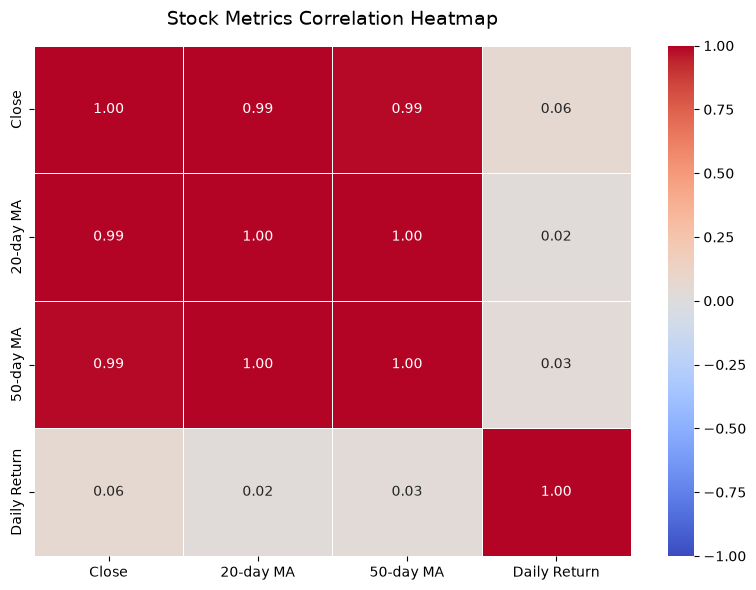

In [76]:
#import matplotlib.pyplot as plt
#import seaborn as sns

#
correlation_matrix = df[["Close", "20-day MA", "50-day MA", "Daily Return"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,       # Shows the correlation coefficients in the squares 
    cmap="coolwarm",  # Diverging colour palette (blue = negative, red = positive)
    vmin=-1,
    vmax=1,           # Sets the limits of the colour bar (-1 to 1)
    center=0,         # Centers the colour scale at 0 (neutral)
    fmt=".2f",        # Rounds numbers to 2 decimal places
    linewidths=0.5,   # Adds lines between the squares
)

#
plt.title("Stock Metrics Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


With 20-day MA & 50-day MA figures are close to 1 and 20-day MA is higher than 50-day MA,
  close price is highly correlated with recent price(s)

??? For daily return, as the values is close to zero with others, this indicates ... (no correlation) TERM


In [77]:
# Configuration

# For ~ 80:20 Split
test_days = 135


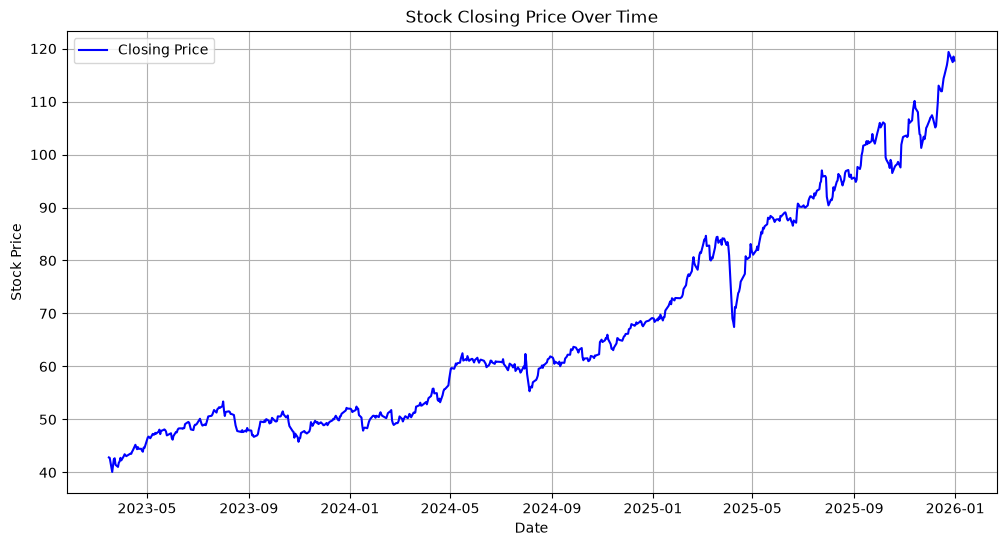

In [78]:
# EDA to explore trends and patterns

plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Closing Price Over Time")  
plt.plot(df['Close'], label="Closing Price", color="blue")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()

7-day MA captures short-term fluctuations while the 50-day MA provides a smoother long-term trend

Sharp deviations between moving averages may indicate trend reversals

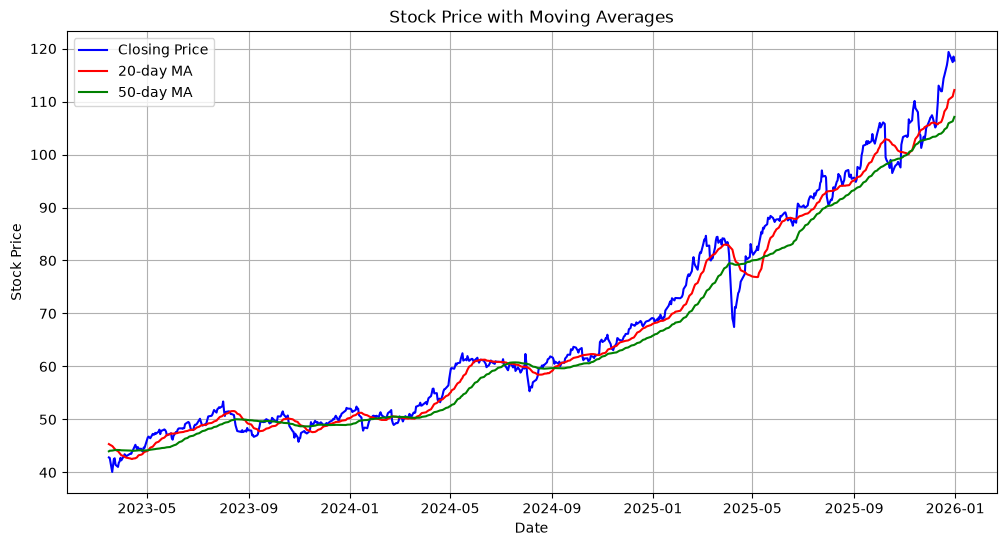

In [79]:
# To smoothen short-term fluctuations with moving averages

plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Price with Moving Averages")
plt.plot(df['Close'], label="Closing Price", color="blue")
plt.plot(df['20-day MA'], label="20-day MA", color="red")
plt.plot(df['50-day MA'], label="50-day MA", color="green")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()


20-day MA captures short-term fluctuations while the 50-day MA provides smoother medium-term trend

Sharp deviations between moving averages may indicate trend reversals

Large spikes indicate high volatility days

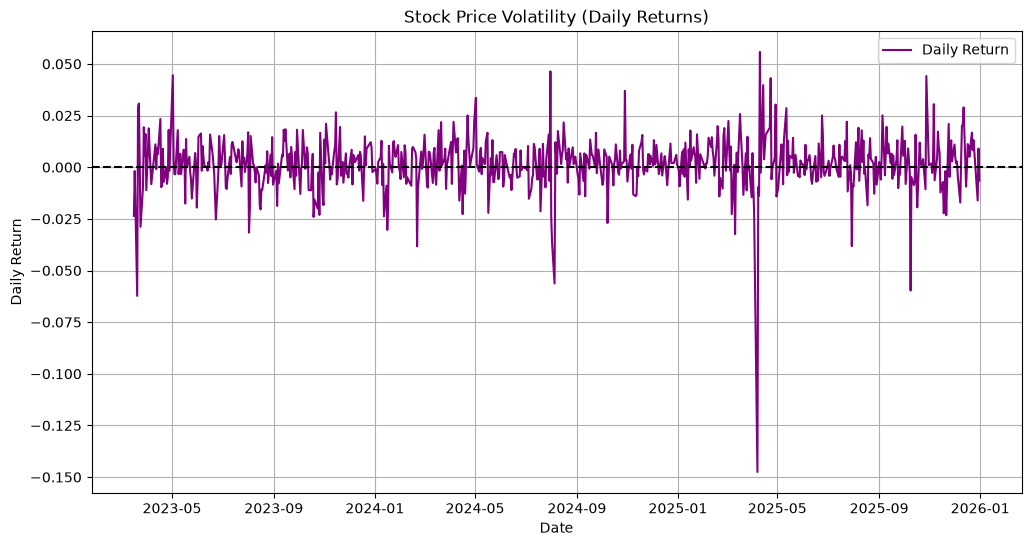

In [80]:
# To analyse Volatility

plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Stock Price Volatility (Daily Returns)")
plt.plot(df['Daily Return'], label="Daily Return", color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

In [52]:
# To check basic statistical details
df.describe()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
count,686.000000,686.000000,686.000000,686.000000,6.860000e+02,686.000000,686.000000,686.000000
mean,407.206988,412.446018,402.177955,407.471655,2.183908e+07,403.620223,398.102355,0.001044
std,111.235586,112.097009,110.319190,111.511835,1.403414e+07,108.229461,102.289140,0.020099
min,254.736938,263.869378,252.793865,258.428775,0.000000e+00,271.126761,274.074403,-0.125352
25%,318.036446,323.521734,315.475283,320.412794,1.430707e+07,320.766641,324.031796,-0.010690
50%,371.592438,375.410844,367.942591,370.522145,1.827510e+07,369.728513,365.484157,0.000000
75%,494.982986,500.233496,489.357245,494.864212,2.471760e+07,490.779267,479.663532,0.011279
max,669.697388,675.134065,662.283778,672.168613,1.470149e+08,646.888147,634.774288,0.081797


In [81]:
# For normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Daily Return'].values.reshape(-1,1))

In [82]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Daily Return']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -15.982761790265506
p-value: 6.806501099801462e-29
The series is stationary.


??? Where to place...

Stock prices fluctuate due to various factors: company earnings, economic trends, geopolitical events, and market sentiment. While no model can predict prices with 100% accuracy, deep learning techniques like LSTMs may discover trends and patterns in historical data.

Traditional models like ARIMA and Exponential Smoothing work well for linear time series, but struggle with the long-term dependencies in stock market data. LSTMs overcome these limitations by learning long-term relationships for financial forecasting.

For this study, we will focus on the adj closing price with Daily Return

#... To export initial data sets

In [83]:
df.isnull().sum()

Close           0
High            0
Low             0
Open            0
Volume          0
20-day MA       0
50-day MA       0
Daily Return    0
dtype: int64

In [84]:
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,


In [57]:
# Prepare for initial set of data for analysis
dftune = df
dftune = dftune.rename(columns={"Daily Return": "Adj Close"})


In [58]:
dftune [["Adj Close"]].to_csv("0700.HK260102.csv")


In [85]:
dftune [["Adj Close"]].to_csv("0005.HK260102.csv")


In [164]:
dftune [["Adj Close"]].to_csv("^hsi260102.csv")


In [188]:
dftune [["Adj Close"]].to_csv("^GSPC260102.csv")


In [29]:
dftune [["Adj Close"]].to_csv("AAPL260102.csv")


...